# Visualizing categorical data

📄 Source: https://seaborn.pydata.org/tutorial/categorical.html

When one of the main variables is **categorical** (discrete groups), use specialised plots. Like `relplot`, there are axes-level functions and one figure-level interface, **`catplot`**, with three families:

| Family | Functions (`kind=`) | Granularity |
| :-- | :-- | :-- |
| Categorical scatterplots | `stripplot` (`"strip"`, default), `swarmplot` (`"swarm"`) | every observation |
| Categorical distribution plots | `boxplot` (`"box"`), `violinplot` (`"violin"`), `boxenplot` (`"boxen"`) | summary of the distribution |
| Categorical estimate plots | `pointplot` (`"point"`), `barplot` (`"bar"`), `countplot` (`"count"`) | one estimate (+ CI) per group |

Pick based on the question you want to answer; the shared API makes switching easy.

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="ticks", color_codes=True)
np.random.seed(sum(map(ord, "categorical")))   # docs' seed, so jitter and CIs match
print("seaborn", sns.__version__)

seaborn 0.13.2


## Categorical scatterplots

Problem: all points of one category land on the **same position** on the categorical axis. Two solutions.

`stripplot` (the default kind) adds a small random **jitter**:

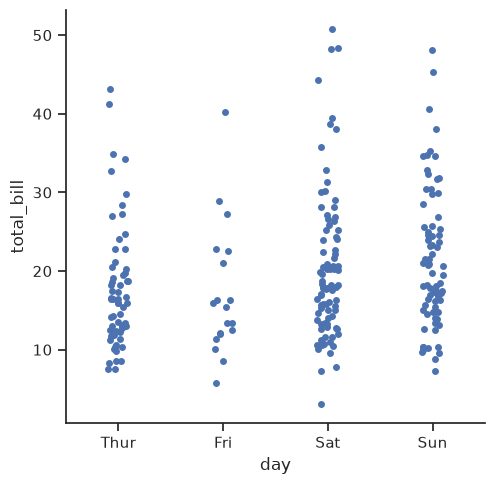

In [2]:
tips = sns.load_dataset("tips")
sns.catplot(data=tips, x="day", y="total_bill")

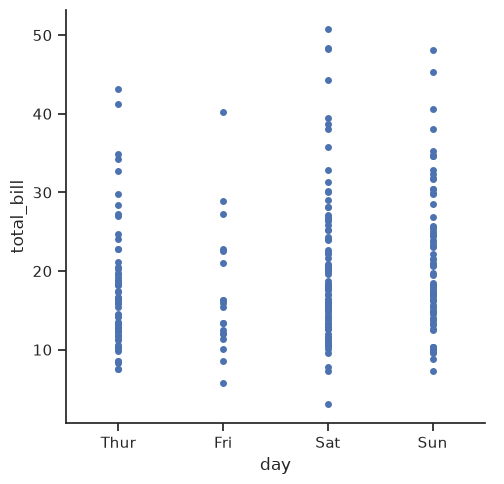

In [3]:
sns.catplot(data=tips, x="day", y="total_bill", jitter=False)   # no jitter: points pile up

`swarmplot` ("beeswarm") moves points with an algorithm so they **don't overlap**. Shows the distribution better, but only for fairly small datasets:

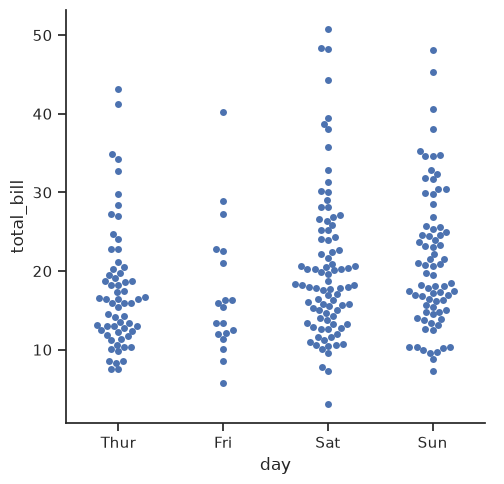

In [4]:
sns.catplot(data=tips, x="day", y="total_bill", kind="swarm")

`hue` adds a dimension (categorical plots have no `size`/`style`). For scatterplots it just colours the points:

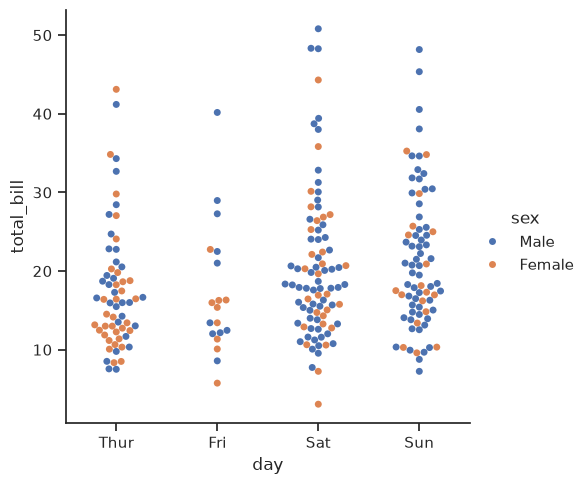

In [5]:
sns.catplot(data=tips, x="day", y="total_bill", hue="sex", kind="swarm")

**Category order:** seaborn infers it from the data. A pandas `Categorical` dtype sets the order. Numeric-looking levels are sorted but still drawn at ordinal positions 0, 1, 2... (note: no gap where size 3 is missing):

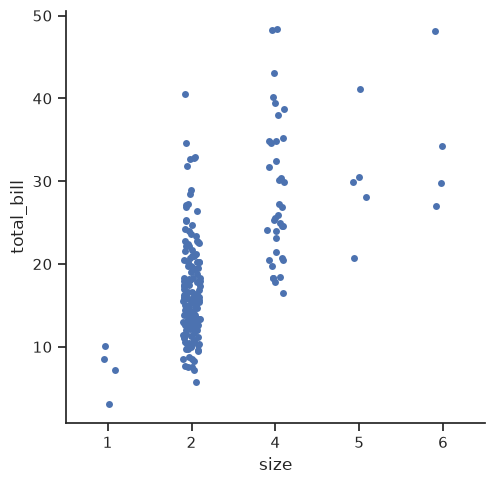

In [6]:
sns.catplot(data=tips.query("size != 3"), x="size", y="total_bill")

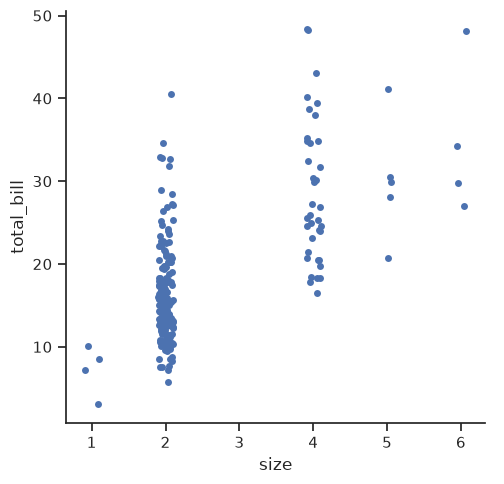

In [7]:
# native_scale=True (v0.13+): group by the numbers but keep their real positions (gap at 3)
sns.catplot(data=tips.query("size != 3"), x="size", y="total_bill", native_scale=True)

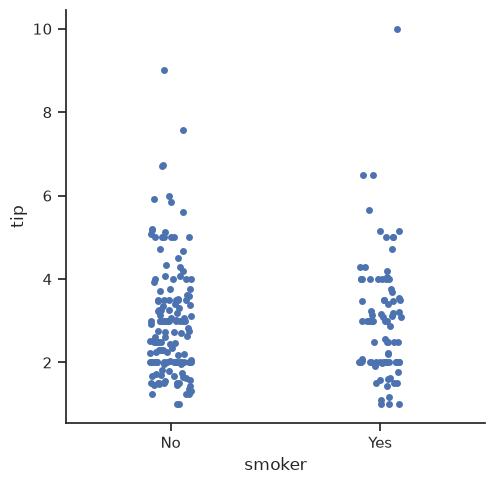

In [8]:
# Control the order per plot with order=
sns.catplot(data=tips, x="smoker", y="tip", order=["No", "Yes"])

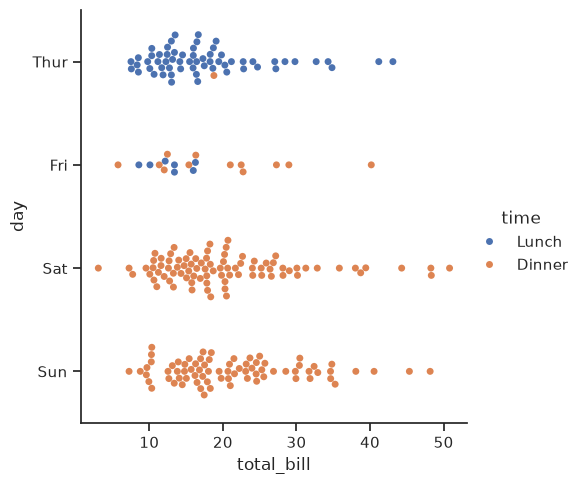

In [9]:
# Categorical axis on the vertical: just swap x and y (good for long or many category names)
sns.catplot(data=tips, x="total_bill", y="day", hue="time", kind="swarm")

## Comparing distributions

With more data, scatterplots stop being informative. Summarise each category's distribution instead.

### Boxplots

Shows the **three quartiles** and extreme values. Whiskers reach the furthest points within **1.5 × IQR** of the box; points beyond are drawn individually (outliers). Every element corresponds to a real observation.

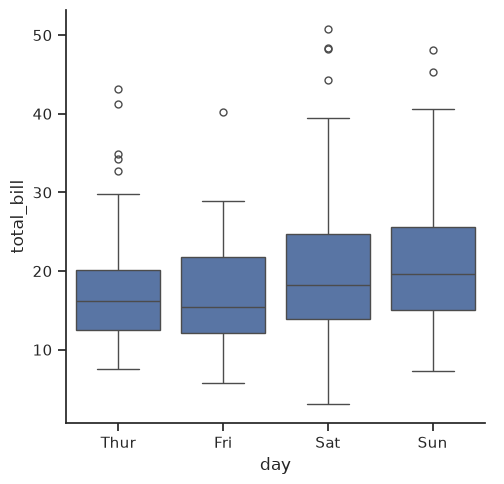

In [10]:
sns.catplot(data=tips, x="day", y="total_bill", kind="box")

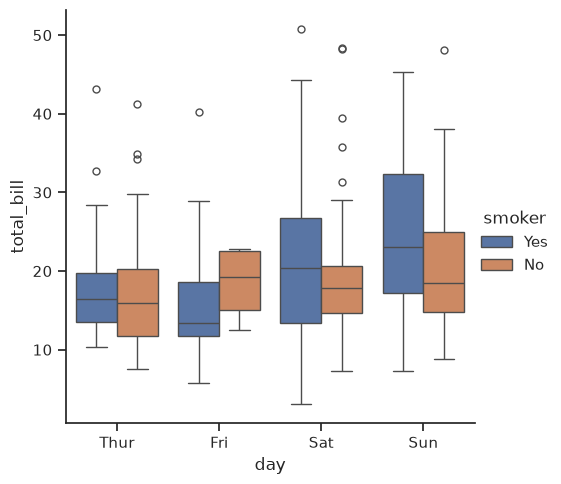

In [11]:
# hue -> narrower boxes, shifted side by side ("dodging")
sns.catplot(data=tips, x="day", y="total_bill", hue="smoker", kind="box")

Dodging is controlled by `dodge`. Since v0.13 boxes dodge **only if they would overlap**. Here `weekend` never overlaps within a day, so no dodging:

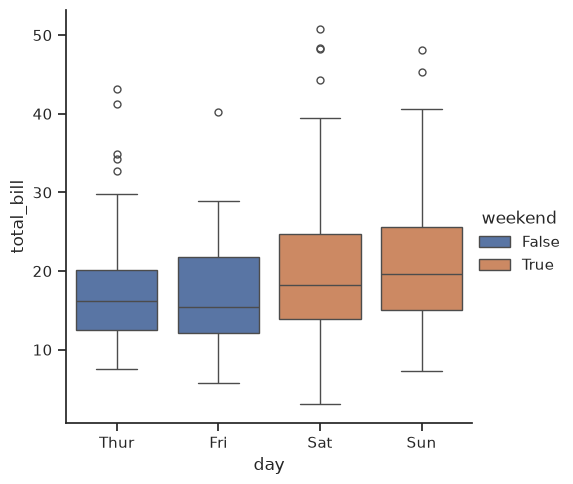

In [12]:
tips["weekend"] = tips["day"].isin(["Sat", "Sun"])
sns.catplot(data=tips, x="day", y="total_bill", hue="weekend", kind="box")

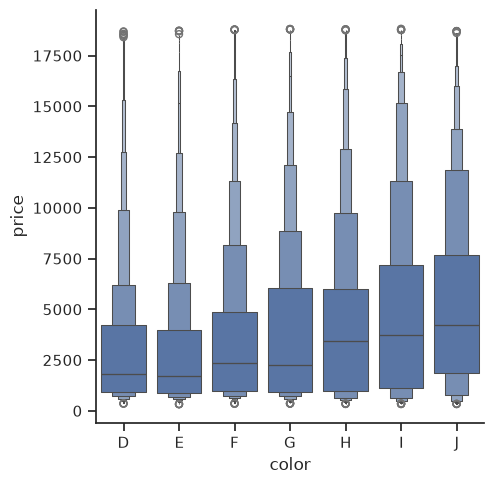

In [13]:
# boxenplot: like a boxplot, with more quantile boxes -> more shape detail, for larger datasets
diamonds = sns.load_dataset("diamonds")
sns.catplot(
    data=diamonds.sort_values("color"),
    x="color", y="price", kind="boxen",
)

### Violinplots

A boxplot + a **KDE** (from notebook 06) of each distribution:

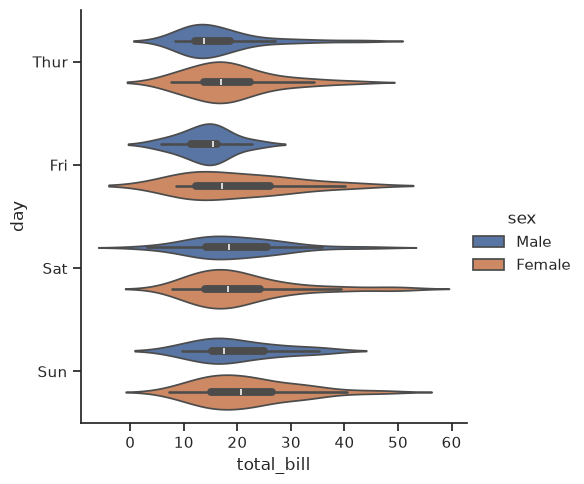

In [14]:
sns.catplot(
    data=tips, x="total_bill", y="day", hue="sex", kind="violin",
)

Richer description, with the quartiles still shown inside. Downside: KDE parameters may need tweaking (`bw_adjust`, `cut`), so it's more complex than a boxplot:

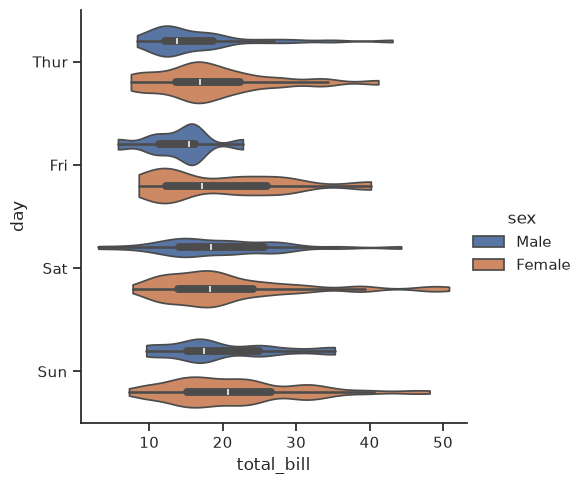

In [15]:
sns.catplot(
    data=tips, x="total_bill", y="day", hue="sex",
    kind="violin", bw_adjust=.5, cut=0,   # less smoothing, don't extend past the data
)

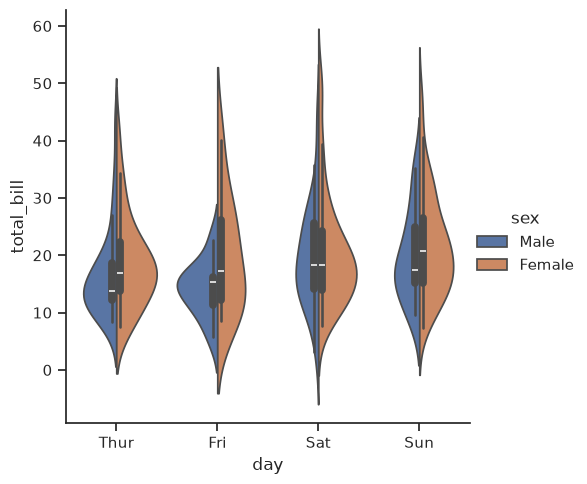

In [16]:
# split=True: one half per hue level, saves space
sns.catplot(
    data=tips, x="day", y="total_bill", hue="sex",
    kind="violin", split=True,
)

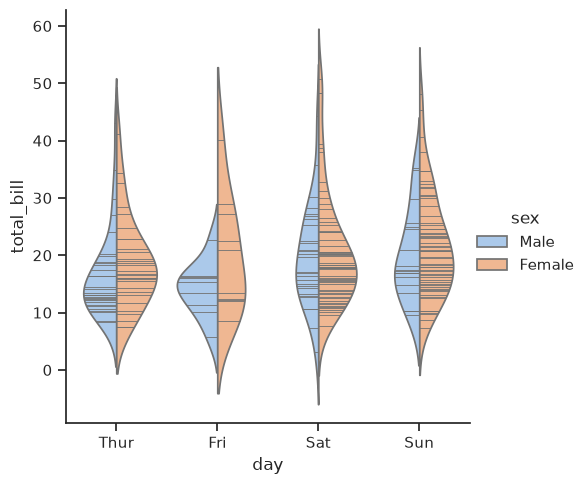

In [17]:
# inner="stick": a line per observation instead of the box summary
sns.catplot(
    data=tips, x="day", y="total_bill", hue="sex",
    kind="violin", inner="stick", split=True, palette="pastel",
)

<Axes: xlabel='day', ylabel='total_bill'>

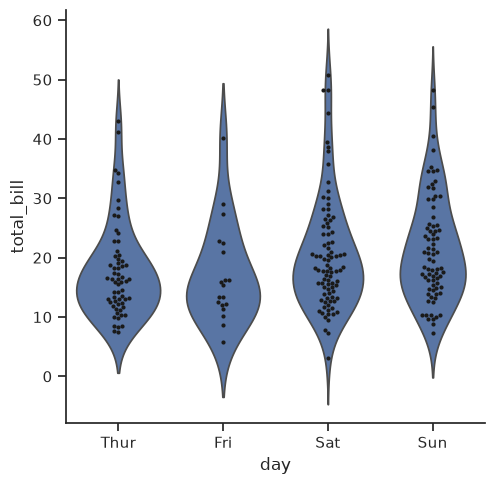

In [18]:
# Combine: violin for the summary + swarm for every observation, drawn on the same Axes (g.ax)
g = sns.catplot(data=tips, x="day", y="total_bill", kind="violin", inner=None)
sns.swarmplot(data=tips, x="day", y="total_bill", color="k", size=3, ax=g.ax)

## Estimating central tendency

Instead of the whole distribution, show an **estimate** of the centre per category. Same API as above.

### Bar plots

`barplot` applies a function to the full dataset (**mean** by default) and draws **bootstrapped 95% CI** error bars.
⚠️ A seaborn bar is a **mean + CI, not a count**.

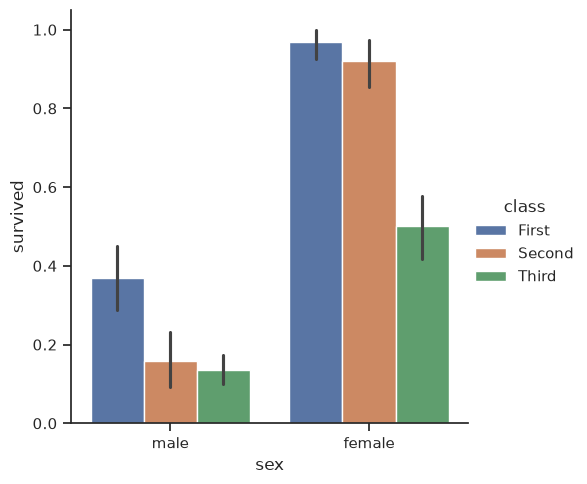

In [19]:
titanic = sns.load_dataset("titanic")
sns.catplot(data=titanic, x="sex", y="survived", hue="class", kind="bar")   # mean of 0/1 = survival rate

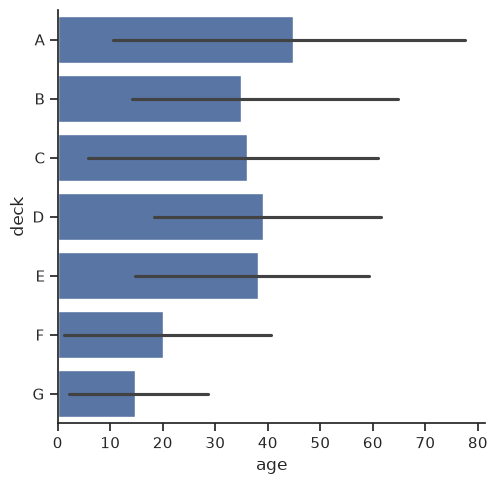

In [20]:
# Other error bar types (v0.12+): here a 95% percentile interval (the spread of the data)
sns.catplot(data=titanic, x="age", y="deck", errorbar=("pi", 95), kind="bar")

To show the **number of observations** per category (a histogram for a categorical variable), use `countplot`:

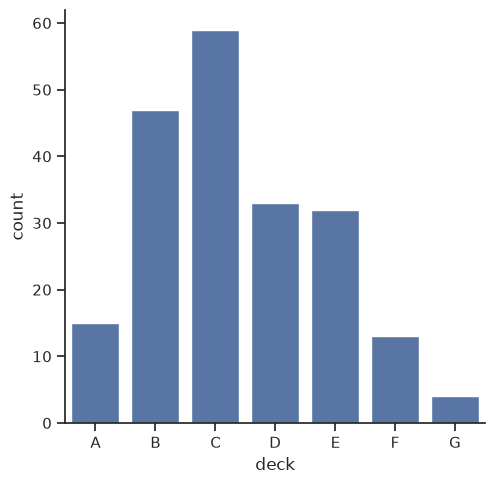

In [21]:
sns.catplot(data=titanic, x="deck", kind="count")

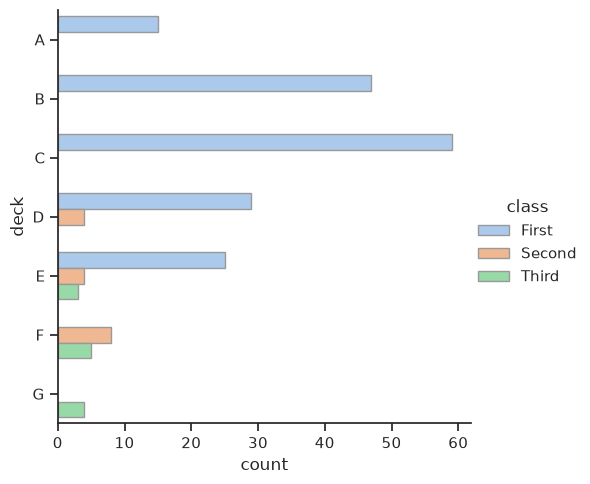

In [22]:
sns.catplot(
    data=titanic, y="deck", hue="class", kind="count",
    palette="pastel", edgecolor=".6",
)

### Point plots

Same information as `barplot`, but draws the **point estimate + CI** and **connects** points of the same `hue` level. Your eye is good at comparing **slopes**, so it's easy to see how the relationship changes with `hue`:

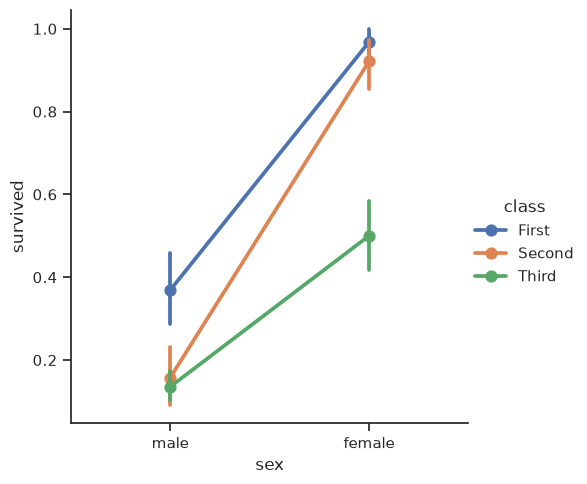

In [23]:
sns.catplot(data=titanic, x="sex", y="survived", hue="class", kind="point")

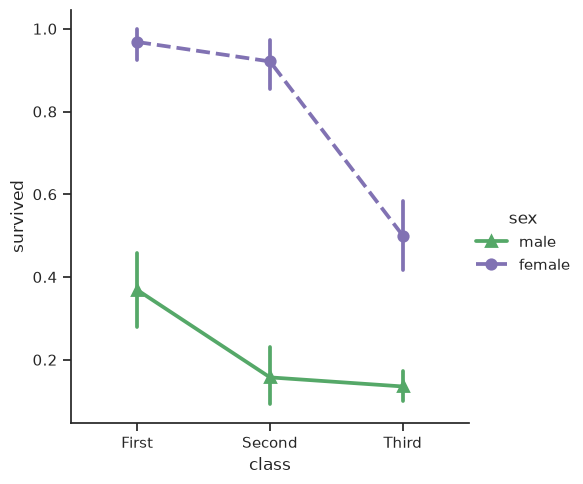

In [24]:
# No style semantic here, but vary markers/linestyles with hue for accessibility and B&W printing
sns.catplot(
    data=titanic, x="class", y="survived", hue="sex",
    palette={"male": "g", "female": "m"},
    markers=["^", "o"], linestyles=["-", "--"],
    kind="point"
)

## Showing additional dimensions

`catplot` is built on `FacetGrid`, so add faceting variables:

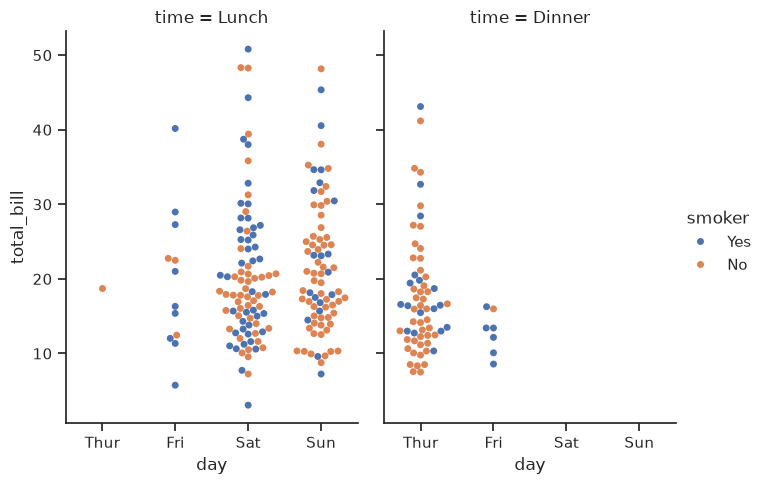

In [25]:
sns.catplot(
    data=tips, x="day", y="total_bill", hue="smoker",
    kind="swarm", col="time", aspect=.7,
)

Customise further with the returned `FacetGrid`, and drop to matplotlib through `g.axes`:

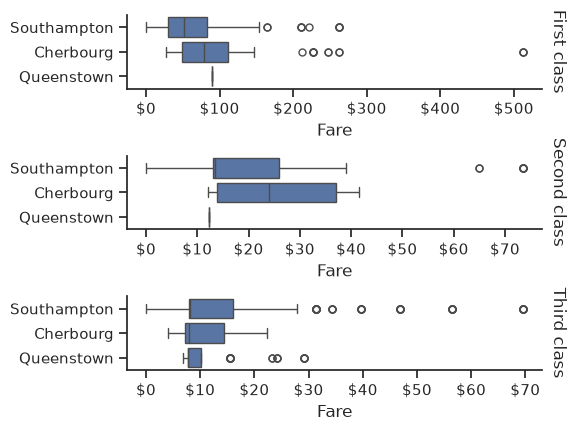

In [26]:
g = sns.catplot(
    data=titanic,
    x="fare", y="embark_town", row="class",
    kind="box", orient="h",
    sharex=False, margin_titles=True,     # each row its own x range; row titles on the right
    height=1.5, aspect=4,
)
g.set(xlabel="Fare", ylabel="")                       # FacetGrid: applies to every Axes
g.set_titles(row_template="{row_name} class")         # FacetGrid: title template
for ax in g.axes.flat:
    ax.xaxis.set_major_formatter('${x:.0f}')          # matplotlib: format ticks as dollars

## Key takeaways

- `catplot(data=, x=, y=, hue=, col=, kind=...)`: strip/swarm → box/violin/boxen → bar/point/count.
- Order categories with a `Categorical` dtype or `order=`; `native_scale=True` keeps numeric spacing.
- Put categories on `y` when names are long.
- **`barplot` = mean + bootstrapped CI**, `countplot` = counts. `pointplot` is best for comparing slopes across `hue`.
- Combine a summary (violin/box) with the raw points (swarm/strip) via `ax=g.ax`.